The fit with detector systematics didnd't see stable. here I check if the minuit minimzer works better. It does. 

I also figured out that some fits were flagged as failed, while the result looked fine. Let's see how many are failed now.

Some fits failed, results look fine. Time to study why the likelihood sometimes gives nan

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from NNMFit.utilities import ScanHandler

# import plotting utils
sys.path.append( "/data/user/tvaneede/utils" )
from FlavourScansPlotting import get_contour_points

# import scanning points
from flavor_fracs import *
points = pd.read_pickle('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor.pickle')
flavs = flavor_frac(np.asarray(points['astro_nue_ratio']),np.asarray(points['astro_nutau_ratio']))

# import plotting flavor triangle
sys.path.append( "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks" )
from plot_utils_triangle import *

# dict with all my dag scans
from scan_dict import scan_dir_dict

In [3]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/flavor_globalfit/study_systematic_fit_problem"
os.system(f"mkdir -p {plotting_path}")

0

In [4]:
# load the data
drop_unsuccessful = False
scan_dict = {}
data = {}
for name in ["hese_allfeat_bdtprod_combinedBase","hese_allfeat_bdtprod_combinedBase_withSyst",
             "hese_allfeat_bdtprod_combinedBase_minuit","hese_allfeat_bdtprod_combinedBase_withSyst_minuit"]:
    print(name)
    scan_dir = scan_dir_dict[name]
    scan_dict[name] = ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
    data[name] = {}
    data[name]["ftau_asimov_poisson"],data[name]["fe_asimov_poisson"],data[name]["ft_grid_asimov_poisson"],data[name]["fe_grid_asimov_poisson"],data[name]["ts_grid_asimov_poisson"] = get_contour_points(scan_dict,name)

hese_allfeat_bdtprod_combinedBase
removed stuff
hese_allfeat_bdtprod_combinedBase_withSyst
removed stuff
hese_allfeat_bdtprod_combinedBase_minuit
removed stuff
hese_allfeat_bdtprod_combinedBase_withSyst_minuit
removed stuff


/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:131: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processi

Area ratio (hese_allfeat_bdtprod_combinedBase / hese_allfeat_bdtprod_combinedBase) at 68%: 1.0000
Area ratio (hese_allfeat_bdtprod_combinedBase_minuit / hese_allfeat_bdtprod_combinedBase) at 68%: 1.0074
Area ratio (hese_allfeat_bdtprod_combinedBase_withSyst / hese_allfeat_bdtprod_combinedBase) at 68%: 0.9272
Area ratio (hese_allfeat_bdtprod_combinedBase_withSyst_minuit / hese_allfeat_bdtprod_combinedBase) at 68%: 0.9819


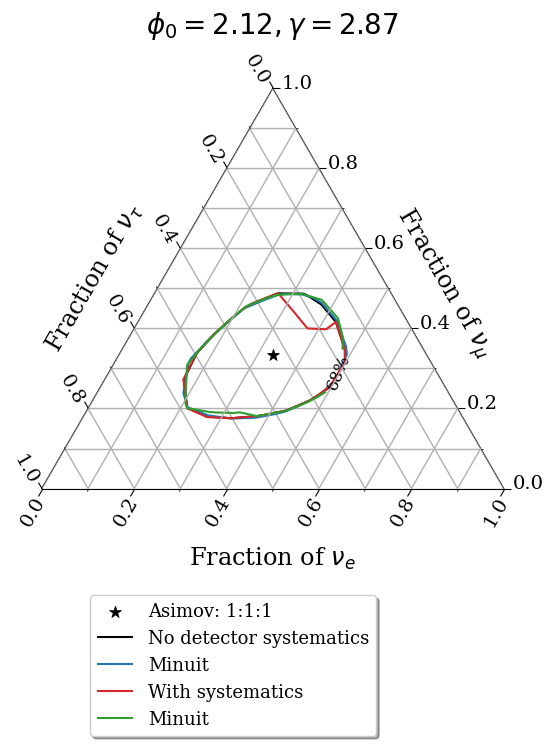

In [5]:
# spice_ftp_oldpid_bdtprod
names = [
"hese_allfeat_bdtprod_combinedBase",
"hese_allfeat_bdtprod_combinedBase_minuit",
"hese_allfeat_bdtprod_combinedBase_withSyst",
"hese_allfeat_bdtprod_combinedBase_withSyst_minuit",
]
labels = [
    "No detector systematics",
    "Minuit",
    "With systematics",
    "Minuit",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = None)

for name in names: compare_area( C, alt_key=name, base_key="hese_allfeat_bdtprod_combinedBase", levels=["68%"] )

In [12]:
for key,handler in scan_dict.items():
    print(10*"-",key)
    scan_df = handler.get_scan_df("astro_nue_ratio-astro_nutau_ratio")
    print(len(scan_df), "rows", handler.drop_unsuccessful())

---------- hese_allfeat_bdtprod_combinedBase
103 rows None
---------- hese_allfeat_bdtprod_combinedBase_withSyst
103 rows None
---------- hese_allfeat_bdtprod_combinedBase_minuit
102 rows None
---------- hese_allfeat_bdtprod_combinedBase_withSyst_minuit
96 rows None
